In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("../data/processed/features_daily_sales.csv")
data["ds"] = pd.to_datetime(data["ds"])
data = data.sort_values("ds").set_index("ds")

data.head(), data.shape

(                 y  day_of_week  month  day_of_month  week_of_year  \
 ds                                                                   
 2021-01-31  779.95            6      1            31             4   
 2021-02-01  340.40            0      2             1             5   
 2021-02-02  411.35            1      2             2             5   
 2021-02-03    0.00            2      2             3             5   
 2021-02-04  424.55            3      2             4             5   
 
             is_weekend   lag_1   lag_7  lag_14  roll_mean_7  roll_std_7  \
 ds                                                                        
 2021-01-31           1  571.15  761.85  834.20   447.207143  235.653099   
 2021-02-01           0  779.95  438.30  451.05   433.221429  239.149021   
 2021-02-02           0  340.40  431.05  416.35   430.407143  239.294702   
 2021-02-03           0  411.35    0.00    0.00   430.407143  239.294702   
 2021-02-04           0    0.00  397.30  441.

In [3]:
split_idx = int(len(data) * 0.8)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

X_train = train.drop(columns=["y"])
y_train = train["y"]

X_test = test.drop(columns=["y"])
y_test = test["y"]

len(train), len(test)

(486, 122)

In [4]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [5]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

MAE  : 162.37
RMSE : 230.11


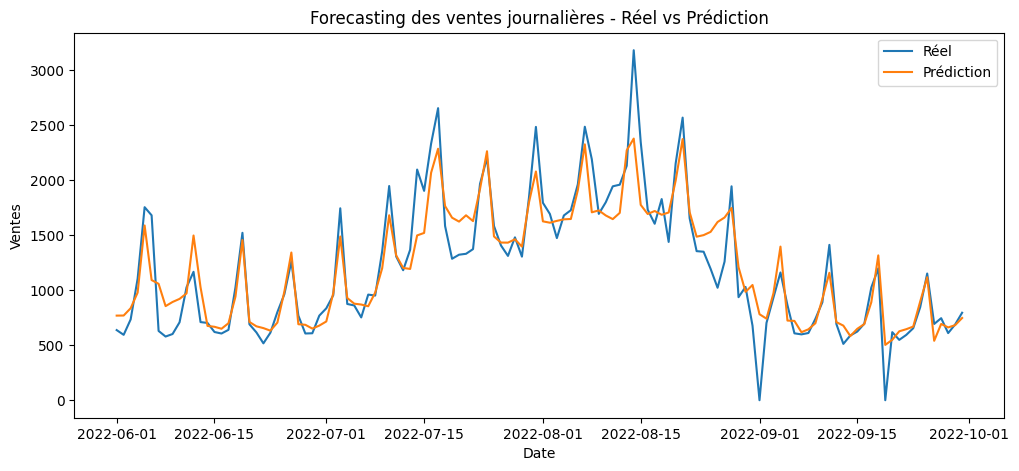

In [ ]:
pred_series = pd.Series(y_pred, index=X_test.index, name="y_pred")

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test.values, label="Réel")
plt.plot(pred_series.index, pred_series.values, label="Prédiction")
plt.title("Forecasting des ventes journalières ( Réel vs Prédiction )")
plt.xlabel("Date")
plt.ylabel("Ventes")
plt.legend()
plt.show()

In [7]:
results = pd.DataFrame({"y_true": y_test, "y_pred": y_pred}, index=X_test.index)
results["residual"] = results["y_true"] - results["y_pred"]
results.to_csv("../data/processed/forecast_results.csv")
print("Sauvegardé : data/processed/forecast_results.csv")

Sauvegardé : data/processed/forecast_results.csv
